# Análisis Exploratorio (EDA) — Precios de Salmón
### Vinson Digital · Case Study


**Productos:**
- **Brazil HON** — precio neto USD/kg FCA (calibres 10-12, 12-14, 14-16 lb)
- **USA Fillet** — precio neto USD/lb FOB Miami (calibres 2/3, 3/4, 4/5)

**Variable objetivo:** precio *real* semanal.
Brazil HON = promedio de las dos lecturas reales (P Real X / P Real XII);
USA Fillet = columna P Real.

---

## 1. Carga y limpieza de datos

In [11]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import STL

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.grid': True, 'grid.alpha': 0.3})

In [20]:
CSV = "../data/raw/Dataset_case_study.csv"

In [21]:
PROD_MAP = {'Brazil HON — Precio neto USD/kg FCA': 'Brazil HON',
            'USA Fillet — Precio neto USD/lb FOB Miami (spot)': 'USA Fillet'}

def load_raw(path):
    raw = pd.read_csv(path, header=[0, 1, 2])
    lvl0 = pd.Series([c[0] if 'Unnamed' not in c[0] else None for c in raw.columns]).ffill()
    lvl1 = pd.Series([c[1] if 'Unnamed' not in c[1] else None for c in raw.columns]).ffill()
    lvl2 = [c[2] for c in raw.columns]
    cols = []
    for p, cal, col in zip(lvl0, lvl1, lvl2):
        cols.append(col if col in ('Año','Semana') else f'{PROD_MAP.get(p,p)}|{cal}|{col}')
    raw.columns = cols
    raw['Año'] = raw['Año'].astype(int); raw['Semana'] = raw['Semana'].astype(int)
    return raw

def iso_week_to_date(y, w):
    return pd.Timestamp.fromisocalendar(y, min(w, 52), 1)

def build_tidy(path):
    raw = load_raw(path)
    raw['fecha'] = [iso_week_to_date(y, w) for y, w in zip(raw['Año'], raw['Semana'])]
    rec = []
    for cal in ['10-12 lb','12-14 lb','14-16 lb']:
        px  = pd.to_numeric(raw[f'Brazil HON|{cal}|P Real X'],   errors='coerce')
        pxi = pd.to_numeric(raw[f'Brazil HON|{cal}|P Real XII'], errors='coerce')
        precio = pd.concat([px, pxi], axis=1).mean(axis=1)
        for f, p in zip(raw['fecha'], precio):
            rec.append(('Brazil HON', cal, 'USD/kg', f, p))
    for cal in ['2/3','3/4','4/5']:
        precio = pd.to_numeric(raw[f'USA Fillet|{cal}|P Real'], errors='coerce')
        for f, p in zip(raw['fecha'], precio):
            rec.append(('USA Fillet', cal, 'USD/lb', f, p))
    return (pd.DataFrame(rec, columns=['producto','calibre','unidad','fecha','precio'])
              .sort_values(['producto','calibre','fecha']).reset_index(drop=True))

tidy = build_tidy(CSV)
print('Filas:', len(tidy), '| Series:', tidy.groupby(['producto','calibre']).ngroups)
tidy.head()

Filas: 1326 | Series: 6


,producto,calibre,unidad,fecha,precio
0,Brazil HON,10-12 lb,USD/kg,2022-01-03,7.6000
1,Brazil HON,10-12 lb,USD/kg,2022-01-10,7.6058
2,Brazil HON,10-12 lb,USD/kg,2022-01-17,7.6062
3,Brazil HON,10-12 lb,USD/kg,2022-01-24,7.6333
4,Brazil HON,10-12 lb,USD/kg,2022-01-31,8.1000


### Cobertura y completitud de cada serie

In [22]:
tidy.groupby(['producto','calibre']).agg(
    n=('precio','size'), no_nulos=('precio', lambda x: x.notna().sum()),
    desde=('fecha','min'), hasta=('fecha','max'),
    min=('precio','min'), max=('precio','max'), media=('precio','mean')).round(2)

n  no_nulos      desde      hasta   min    max  media
producto   calibre                                                          
Brazil HON 10-12 lb  221       216 2022-01-03 2026-03-23  5.35  10.04   7.46
           12-14 lb  221       217 2022-01-03 2026-03-23  5.45  10.07   7.56
           14-16 lb  221       216 2022-01-03 2026-03-23  5.56  10.05   7.61
USA Fillet 2/3       221       216 2022-01-03 2026-03-23  5.08   7.57   6.14
           3/4       221       217 2022-01-03 2026-03-23  5.13   7.60   6.22
           4/5       221       212 2022-01-03 2026-03-23  5.20   7.78   6.34

In [23]:
def get_series(producto, calibre):
    s = tidy[(tidy.producto==producto)&(tidy.calibre==calibre)] \
        .set_index('fecha')['precio'].asfreq('W-MON')
    return s.interpolate('linear', limit=3, limit_area='inside').dropna()

SERIES = [('Brazil HON','10-12 lb'),('Brazil HON','12-14 lb'),('Brazil HON','14-16 lb'),
          ('USA Fillet','2/3'),('USA Fillet','3/4'),('USA Fillet','4/5')]
series = {f'{p}|{c}': get_series(p,c) for p,c in SERIES}
COLORS = {'Brazil HON|10-12 lb':'#1b4965','Brazil HON|12-14 lb':'#2a6f97',
          'Brazil HON|14-16 lb':'#468faf','USA Fillet|2/3':'#9e2a2b',
          'USA Fillet|3/4':'#c1502e','USA Fillet|4/5':'#e09f3e'}

## 2. Trayectoria histórica

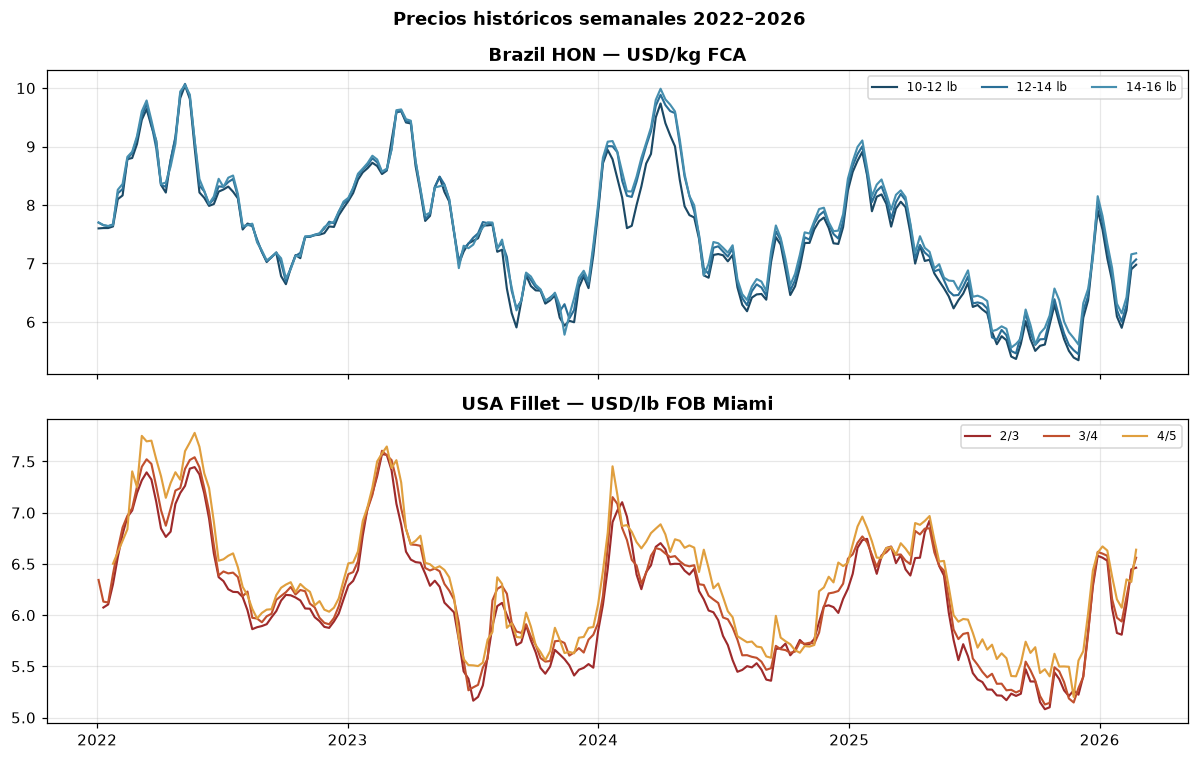

In [24]:
fig, axes = plt.subplots(2,1,figsize=(11,7),sharex=True)
for key,s in series.items():
    ax = axes[0] if key.startswith('Brazil') else axes[1]
    ax.plot(s.index,s.values,label=key.split('|')[1],color=COLORS[key],lw=1.4)
axes[0].set_title('Brazil HON — USD/kg FCA',fontweight='bold')
axes[1].set_title('USA Fillet — USD/lb FOB Miami',fontweight='bold')
for ax in axes:
    ax.legend(ncol=3,fontsize=8); ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
fig.suptitle('Precios históricos semanales 2022–2026',fontweight='bold')
fig.tight_layout(); plt.show()

**Lectura:**
- Tendencia **bajista** sostenida en Brazil HON tras los máximos de 2022-2024.
- **Estacionalidad muy marcada y recurrente**: máximos en Q1-Q2, mínimos a mitad de año.
- Los tres calibres se mueven casi en paralelo, con *premium* estable para los grandes.

## 3. Patrón estacional (índice base 100 = media anual)

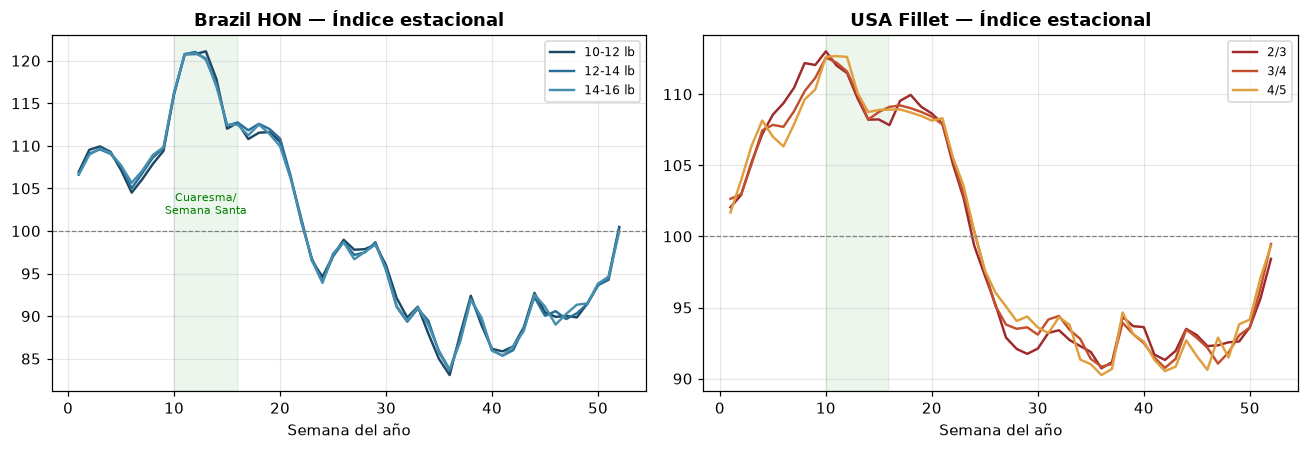

In [25]:
fig, axes = plt.subplots(1,2,figsize=(12,4.2))
for key,s in series.items():
    df = pd.DataFrame({'precio':s}); df['woy']=df.index.isocalendar().week.values
    norm = df.groupby('woy')['precio'].mean(); norm = norm/norm.mean()*100
    ax = axes[0] if key.startswith('Brazil') else axes[1]
    ax.plot(norm.index,norm.values,label=key.split('|')[1],color=COLORS[key],lw=1.6)
for ax,t in zip(axes,['Brazil HON','USA Fillet']):
    ax.axhline(100,color='gray',ls='--',lw=0.8); ax.axvspan(10,16,color='green',alpha=0.07)
    ax.set_title(f'{t} — Índice estacional',fontweight='bold')
    ax.set_xlabel('Semana del año'); ax.legend(fontsize=8)
axes[0].annotate('Cuaresma/\nSemana Santa', xy=(13,102), fontsize=7, color='green', ha='center')
fig.tight_layout(); plt.show()

**Lectura:** el pico de precios se da en las **semanas 10-16 (marzo-abril)**,
coincidente con **Cuaresma / Semana Santa**, llegando a **+15% a +20%** sobre la
media. El **valle** ocurre en las **semanas 35-42 (sept-oct)**, hasta **-15%**.
Este patrón es la palanca comercial más clara.

## 4. Descomposición STL (tendencia · estacional · residuo)

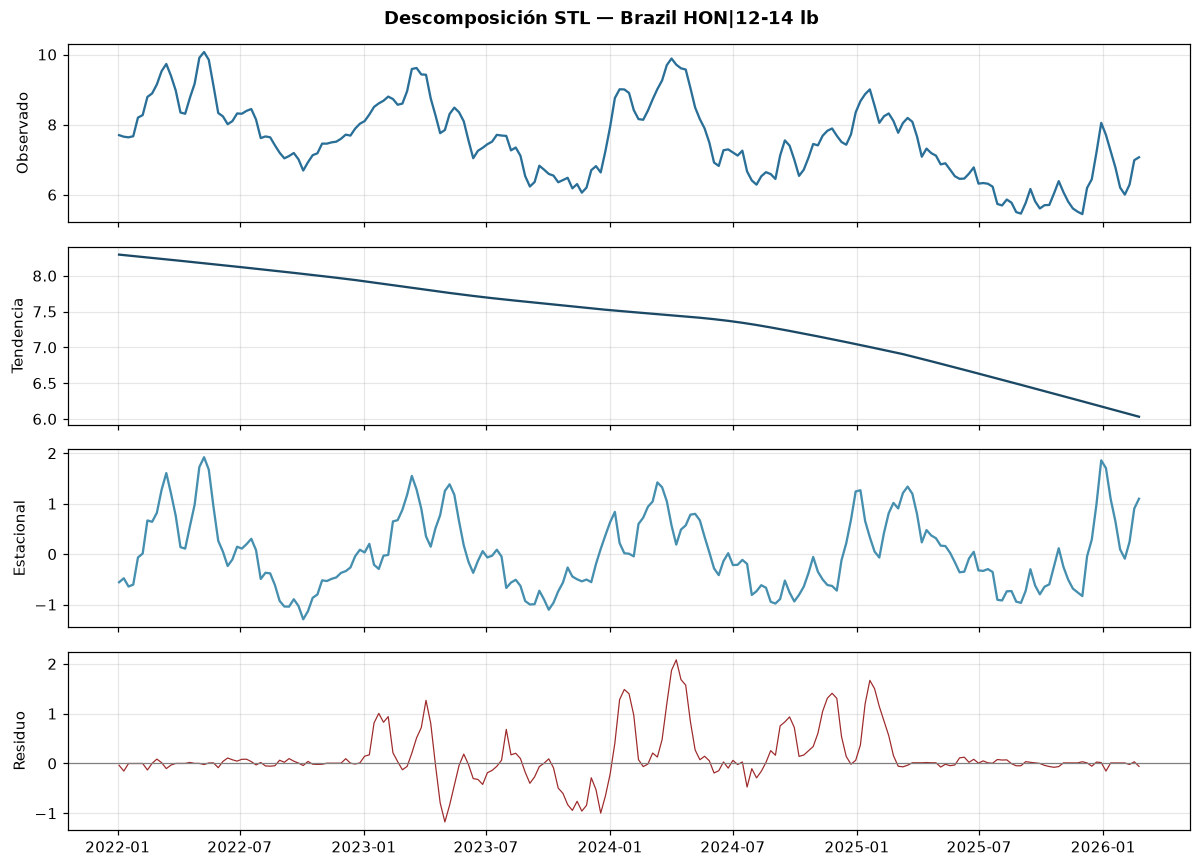

In [26]:
key='Brazil HON|12-14 lb'; s=series[key]
stl = STL(s, period=52, robust=True).fit()
fig,ax=plt.subplots(4,1,figsize=(11,8),sharex=True)
ax[0].plot(s.index,s.values,color=COLORS[key]);    ax[0].set_ylabel('Observado')
ax[1].plot(s.index,stl.trend,color='#1b4965');      ax[1].set_ylabel('Tendencia')
ax[2].plot(s.index,stl.seasonal,color='#468faf');   ax[2].set_ylabel('Estacional')
ax[3].plot(s.index,stl.resid,color='#9e2a2b',lw=.8);ax[3].set_ylabel('Residuo')
ax[3].axhline(0,color='gray',lw=.8)
fig.suptitle(f'Descomposición STL — {key}',fontweight='bold')
fig.tight_layout(); plt.show()

**Lectura:** la descomposición separa una **tendencia bajista** persistente,
una **estacionalidad anual** fuerte y recurrente, y **residuos** contenidos salvo
episodios puntuales (shocks de oferta/demanda).

## 5. Correlaciones entre series y spread de calibres

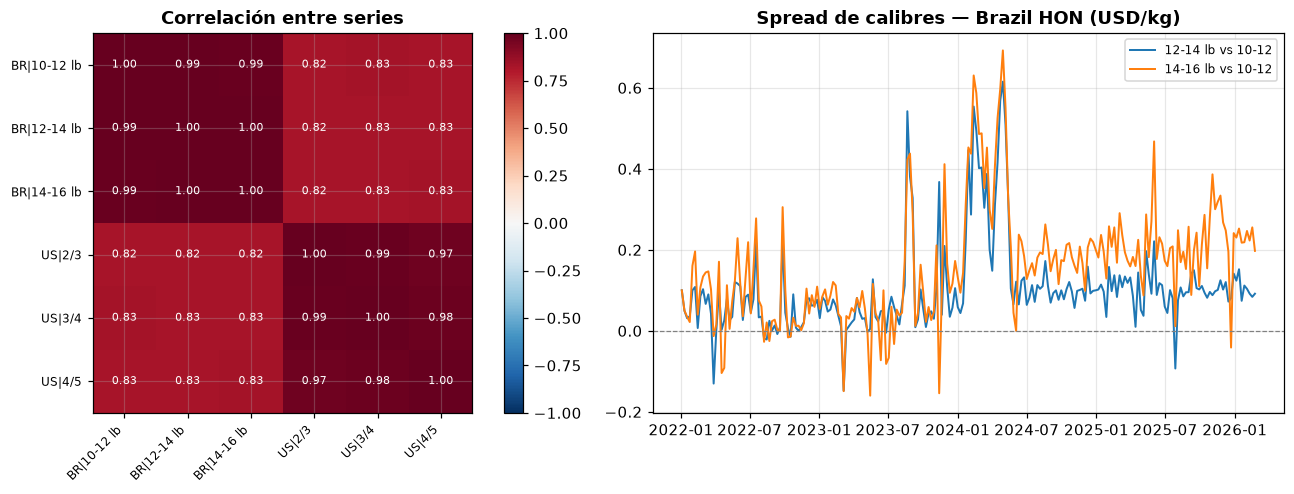

In [27]:
mat = pd.DataFrame({k:v for k,v in series.items()}).dropna()
corr = mat.corr()
fig,(a1,a2)=plt.subplots(1,2,figsize=(13,4.6))
im=a1.imshow(corr,cmap='RdBu_r',vmin=-1,vmax=1)
labs=[k.replace('Brazil HON','BR').replace('USA Fillet','US') for k in corr.columns]
a1.set_xticks(range(len(corr))); a1.set_yticks(range(len(corr)))
a1.set_xticklabels(labs,rotation=45,ha='right',fontsize=8); a1.set_yticklabels(labs,fontsize=8)
for i in range(len(corr)):
    for j in range(len(corr)):
        a1.text(j,i,f'{corr.iloc[i,j]:.2f}',ha='center',va='center',fontsize=7,
                color='white' if abs(corr.iloc[i,j])>0.6 else 'black')
a1.set_title('Correlación entre series',fontweight='bold'); fig.colorbar(im,ax=a1,fraction=0.046)

base=series['Brazil HON|10-12 lb']
for cal in ['12-14 lb','14-16 lb']:
    sp=(series[f'Brazil HON|{cal}']-base).dropna()
    a2.plot(sp.index,sp.values,label=f'{cal} vs 10-12',lw=1.3)
a2.axhline(0,color='gray',ls='--',lw=0.8)
a2.set_title('Spread de calibres — Brazil HON (USD/kg)',fontweight='bold'); a2.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Lectura:** las series están **altamente correlacionadas** dentro de cada
producto

## 6. Volatilidad y anomalías

In [29]:
rows=[]
for key,s in series.items():
    ret=s.pct_change().dropna()
    yoy=(s.iloc[-1]/s.shift(52).dropna().iloc[-1]-1)*100
    rows.append({'serie':key,'precio_actual':round(s.iloc[-1],2),
                 'vol_sem_%':round(ret.std()*100,2),
                 'vol_anual_%':round(ret.std()*np.sqrt(52)*100,1),
                 'min':round(s.min(),2),'max':round(s.max(),2),'YoY_%':round(yoy,1)})
pd.DataFrame(rows)

,serie,precio_actual,vol_sem_%,vol_anual_%,min,max,YoY_%
0,Brazil HON|10-12 lb,6.98,4.43,31.9,5.35,10.04,-13.0
1,Brazil HON|12-14 lb,7.07,4.28,30.9,5.45,10.07,-12.8
2,Brazil HON|14-16 lb,7.17,4.34,31.3,5.56,10.05,-12.4
3,USA Fillet|2/3,6.46,2.58,18.6,5.08,7.57,-2.9
4,USA Fillet|3/4,6.56,2.54,18.3,5.13,7.60,-0.8
5,USA Fillet|4/5,6.64,2.79,20.1,5.20,7.78,-0.3


In [30]:
# Anomalías: residuo STL > 3 desviaciones estándar
resid = pd.Series(stl.resid, index=s.index)
z = (resid-resid.mean())/resid.std()
anom = z[abs(z)>3]
print(f'Anomalías (>3σ) en {key}:')
for f,zz in anom.items():
    print(f'  {f.date()}  z={zz:+.1f}  precio={series[key].loc[f]:.2f}')

Anomalías (>3σ) en USA Fillet|4/5:
  2024-04-01  z=+3.4  precio=6.89
  2024-04-08  z=+3.8  precio=6.79
  2024-04-15  z=+3.0  precio=6.62
  2025-01-20  z=+3.0  precio=6.96


**Lectura:** Brazil HON es **~1.6x más volátil** que USA Fillet
(≈31% vs ≈19% anualizado): el precio USD/kg FCA reacciona más a la oferta de
cosecha, mientras el filete FOB Miami es más estable por su mercado de destino.

---

### Conclusiones
1. **Estacionalidad fuerte y recurrente** (semana santa => alta demanda, valle sept-oct) → principal señal predecible.
2. **Tendencia bajista** en Brazil HON desde 2022-2024.
3. **Brazil HON más volátil** que USA Fillet.
4. **Alta correlación** entre calibres.
